<a href="https://colab.research.google.com/github/Huang-stat/Computer-Labs/blob/main/AKHU_CS_Lab3A_Data_Input_EDA_Model_Comparison_0507.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS Lab 3A: Python Data Input, EDA, and First Model Comparison

**Date/time:** Thursday, 7 May 2026, 16:00  
**Room:** Comp. Lab 1  
**Topic:** Colab demonstration with Visual Studio Code remarks

This notebook uses only built-in Python modules for the core workflow. That reduces package-installation problems in Visual Studio Code. Colab users may still use `pandas` later, but this lab first makes the file path and data structure clear.

## 0. Colab versus Visual Studio Code

### Colab
- Python runs on a temporary cloud computer.
- Quick upload files usually appear in `/content`.
- Google Drive files appear under `/content/drive/MyDrive/...` after mounting Drive.

### Visual Studio Code
- Python runs on your computer.
- The current working directory is usually the folder opened in VS Code.
- Recommended layout:

```text
AKHU_lab3/
  Lab3A.ipynb
  Lab3B.ipynb
  data/
    AKHU_student_scores_cs_lab3_clean.csv
    AKHU_student_scores_cs_lab3_messy.csv
```

Run `Path.cwd()` before loading data. This single habit prevents many file-loading errors.

In [1]:
from pathlib import Path
import csv
import statistics
import math

print("Current working directory:", Path.cwd())

# Colab notes:
# 1. Quick demo: upload CSV files to /content.
# 2. Persistent demo: mount Google Drive and put files in /content/drive/MyDrive/AKHU_labs.
#
# Uncomment these lines only inside Colab when you want to mount Google Drive:
# from google.colab import drive
# drive.mount("/content/drive")

CANDIDATE_DIRS = [
    Path("data"),
    Path("."),
    Path("/content"),
    Path("/content/data"),
    Path("/content/drive/MyDrive/AKHU_labs"),
]

def find_data_file(filename):
    for folder in CANDIDATE_DIRS:
        candidate = folder / filename
        if candidate.exists():
            print(f"Found {filename} at: {candidate}")
            return candidate
    searched = "\n".join(str(folder.resolve()) if folder.exists() else str(folder) for folder in CANDIDATE_DIRS)
    raise FileNotFoundError(f"Could not find {filename}. Searched:\n{searched}")

Current working directory: /content


## 0A. Plotting setup for result figures

This notebook shows only data-analysis and model-comparison plots. It does not use markdown attachments, so it is safe for GitHub and nbconvert.

In [2]:
# Plotting setup
# Colab usually has matplotlib installed.
# In VS Code, install it only if this import gives an error:
#     python -m pip install matplotlib

from pathlib import Path
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

ASSETS_DIR = Path("assets")
ASSETS_DIR.mkdir(exist_ok=True)


def save_and_show_current_figure(filename):
    """Save the current figure and show it directly below this code cell."""
    path = ASSETS_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.close()
    print("Saved figure:", path)
    display(Image(filename=str(path)))


## 1. Find and read the clean CSV file

The CSV file is a rectangular table: rows are students and columns are variables.
Python's built-in `csv.DictReader` reads each row as a dictionary.

In [3]:
clean_path = find_data_file("AKHU_student_scores_cs_lab3_clean.csv")

with clean_path.open(newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    rows = list(reader)
    column_names = reader.fieldnames

print("Number of rows:", len(rows))
print("Column names:", column_names)
print("First row:")
print(rows[0])

Found AKHU_student_scores_cs_lab3_clean.csv at: AKHU_student_scores_cs_lab3_clean.csv
Number of rows: 12
Column names: ['student_id', 'hours_studied', 'attendance_rate', 'assignments_submitted', 'quiz_average', 'final_score']
First row:
{'student_id': 'S01', 'hours_studied': '1.5', 'attendance_rate': '0.55', 'assignments_submitted': '4', 'quiz_average': '48', 'final_score': '52'}


## 2. Convert selected columns from text to numbers

CSV cells are read as text. Modeling requires numbers. We convert only the columns needed today.

In [4]:
NUMERIC_COLUMNS = ["hours_studied", "attendance_rate", "assignments_submitted", "quiz_average", "final_score"]

for row in rows:
    for col in NUMERIC_COLUMNS:
        row[col] = float(row[col])

print(rows[0])
print("Type of final_score after conversion:", type(rows[0]["final_score"]))

{'student_id': 'S01', 'hours_studied': 1.5, 'attendance_rate': 0.55, 'assignments_submitted': 4.0, 'quiz_average': 48.0, 'final_score': 52.0}
Type of final_score after conversion: <class 'float'>


## 3. EDA: numerical summaries

EDA means exploratory data analysis. Start with simple questions:

- What is the average final score?
- How spread out are the scores?
- What are the minimum and maximum scores?

In [5]:
def summarize_column(rows, column):
    values = [row[column] for row in rows]
    return {
        "count": len(values),
        "mean": statistics.mean(values),
        "median": statistics.median(values),
        "min": min(values),
        "max": max(values),
        "std": statistics.stdev(values),
    }

summary = summarize_column(rows, "final_score")
for key, value in summary.items():
    print(f"{key:>6}: {value:.3f}" if isinstance(value, float) else f"{key:>6}: {value}")

 count: 12
  mean: 68.917
median: 69.000
   min: 52.000
   max: 87.000
   std: 11.082


## 4. EDA: relationship question

Question: Does `hours_studied` move together with `final_score`?

Without plotting packages, we can print pairs. In Colab, the instructor may also display plots from the lecture note.

In [6]:
for row in rows:
    print(row["student_id"], "hours =", row["hours_studied"], "final_score =", row["final_score"])

S01 hours = 1.5 final_score = 52.0
S02 hours = 2.0 final_score = 56.0
S03 hours = 2.3 final_score = 59.0
S04 hours = 2.7 final_score = 63.0
S05 hours = 3.0 final_score = 67.0
S06 hours = 3.3 final_score = 71.0
S07 hours = 3.5 final_score = 73.0
S08 hours = 3.8 final_score = 76.0
S09 hours = 4.0 final_score = 79.0
S10 hours = 4.2 final_score = 83.0
S11 hours = 4.4 final_score = 87.0
S12 hours = 2.2 final_score = 61.0


## 4A. EDA result figures

The next cell creates two plots from the loaded data: final scores by student and the relationship between hours studied and final score.

Saved figure: assets/eda_final_score_bar.png


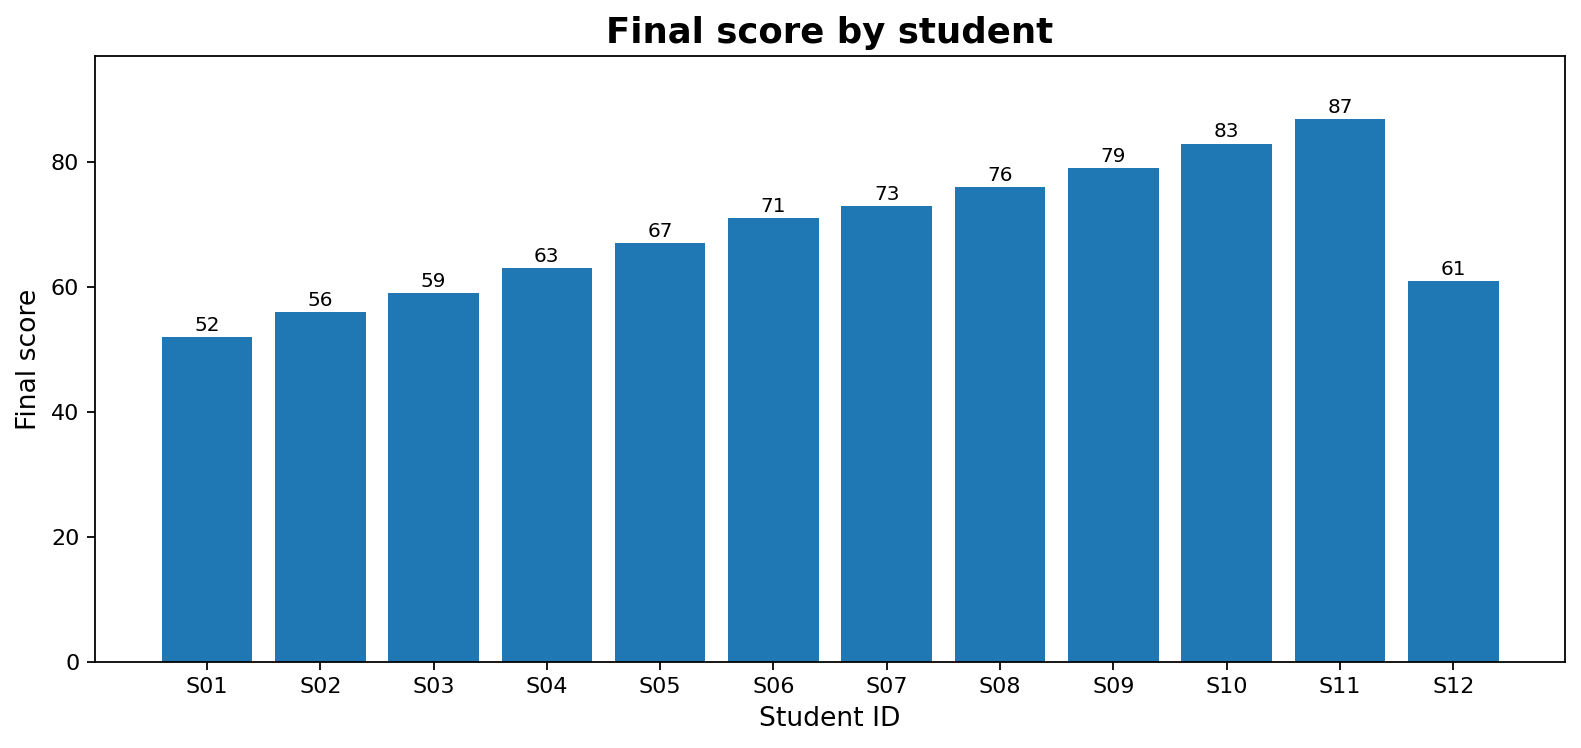

Saved figure: assets/eda_hours_vs_score.png


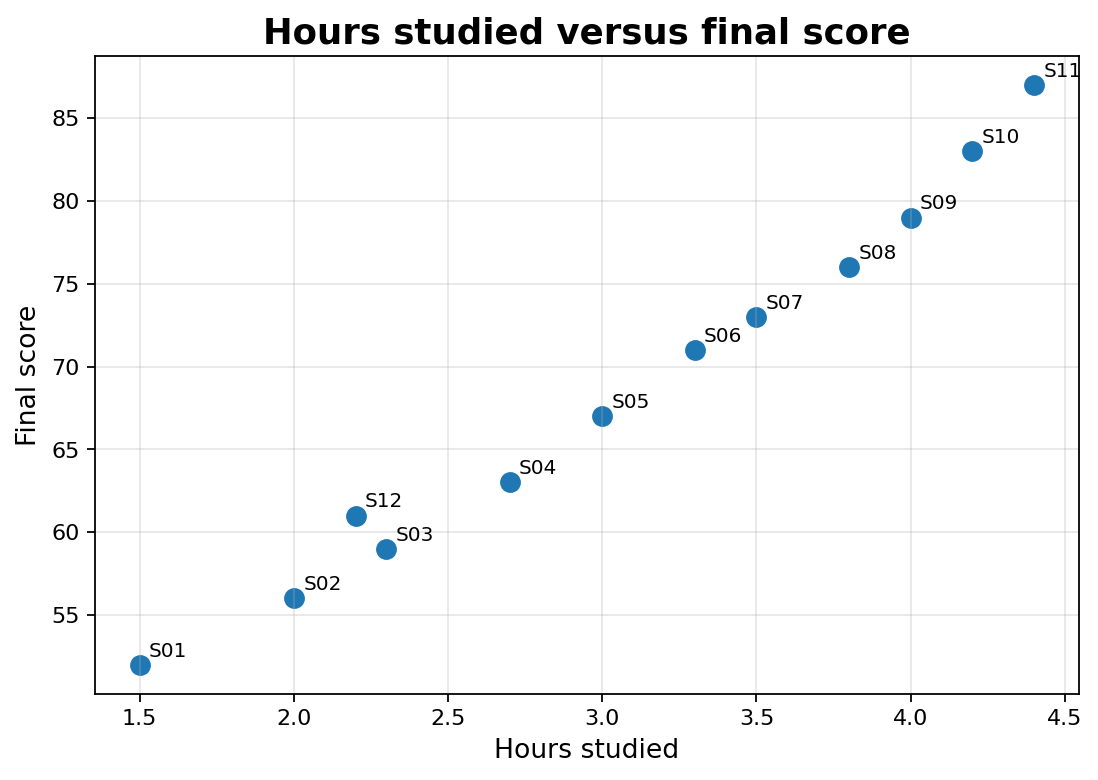

In [7]:
student_ids = [row["student_id"] for row in rows]
final_scores = [row["final_score"] for row in rows]
hours = [row["hours_studied"] for row in rows]

# Plot 1: final score by student
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(student_ids, final_scores)
ax.set_title("Final score by student", fontsize=16, weight="bold")
ax.set_xlabel("Student ID", fontsize=12)
ax.set_ylabel("Final score", fontsize=12)
ax.set_ylim(0, max(final_scores) + 10)
for i, score in enumerate(final_scores):
    ax.text(i, score + 1, f"{score:.0f}", ha="center", fontsize=9)
save_and_show_current_figure("eda_final_score_bar.png")

# Plot 2: hours studied versus final score
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(hours, final_scores, s=70)
for sid, x, y in zip(student_ids, hours, final_scores):
    ax.text(x + 0.03, y + 0.5, sid, fontsize=9)
ax.set_title("Hours studied versus final score", fontsize=16, weight="bold")
ax.set_xlabel("Hours studied", fontsize=12)
ax.set_ylabel("Final score", fontsize=12)
ax.grid(True, alpha=0.3)
save_and_show_current_figure("eda_hours_vs_score.png")


## 5. First model comparison: mean baseline versus simple regression

We use the first 8 rows for training and the last 4 rows for testing.

### Mean baseline
Predict the training mean for every test row.

### Simple regression
Use one feature, `hours_studied`, to predict `final_score`:

\[
\hat{y} = b_0 + b_1 x
\]

In [8]:
def train_test_split(rows, n_train=8):
    return rows[:n_train], rows[n_train:]

def mean_baseline_fit(train_rows, target_col):
    return statistics.mean(row[target_col] for row in train_rows)

def mean_baseline_predict(mean_value, test_rows):
    return [mean_value for _ in test_rows]

def simple_regression_fit(train_rows, x_col, y_col):
    x = [row[x_col] for row in train_rows]
    y = [row[y_col] for row in train_rows]
    x_bar = statistics.mean(x)
    y_bar = statistics.mean(y)
    numerator = sum((xi - x_bar) * (yi - y_bar) for xi, yi in zip(x, y))
    denominator = sum((xi - x_bar) ** 2 for xi in x)
    slope = numerator / denominator
    intercept = y_bar - slope * x_bar
    return intercept, slope

def simple_regression_predict(intercept, slope, test_rows, x_col):
    return [intercept + slope * row[x_col] for row in test_rows]

def mae(actual, predicted):
    return sum(abs(a - p) for a, p in zip(actual, predicted)) / len(actual)

def rmse(actual, predicted):
    return math.sqrt(sum((a - p) ** 2 for a, p in zip(actual, predicted)) / len(actual))

In [9]:
train_rows, test_rows = train_test_split(rows, n_train=8)
y_test = [row["final_score"] for row in test_rows]

mean_value = mean_baseline_fit(train_rows, "final_score")
baseline_pred = mean_baseline_predict(mean_value, test_rows)

intercept, slope = simple_regression_fit(train_rows, "hours_studied", "final_score")
regression_pred = simple_regression_predict(intercept, slope, test_rows, "hours_studied")

print("Regression equation:")
print(f"predicted final_score = {intercept:.3f} + {slope:.3f} * hours_studied")
print()
print("Model comparison")
print("Mean baseline MAE:", round(mae(y_test, baseline_pred), 3))
print("Mean baseline RMSE:", round(rmse(y_test, baseline_pred), 3))
print("Regression MAE:", round(mae(y_test, regression_pred), 3))
print("Regression RMSE:", round(rmse(y_test, regression_pred), 3))

Regression equation:
predicted final_score = 34.718 + 10.826 * hours_studied

Model comparison
Mean baseline MAE: 14.688
Mean baseline RMSE: 16.264
Regression MAE: 2.726
Regression RMSE: 3.022


## 5A. Model-comparison result figures

The next cell creates two modeling-result plots: MAE comparison and actual-versus-predicted values on the test rows.

Saved figure: assets/model_comparison_mae.png


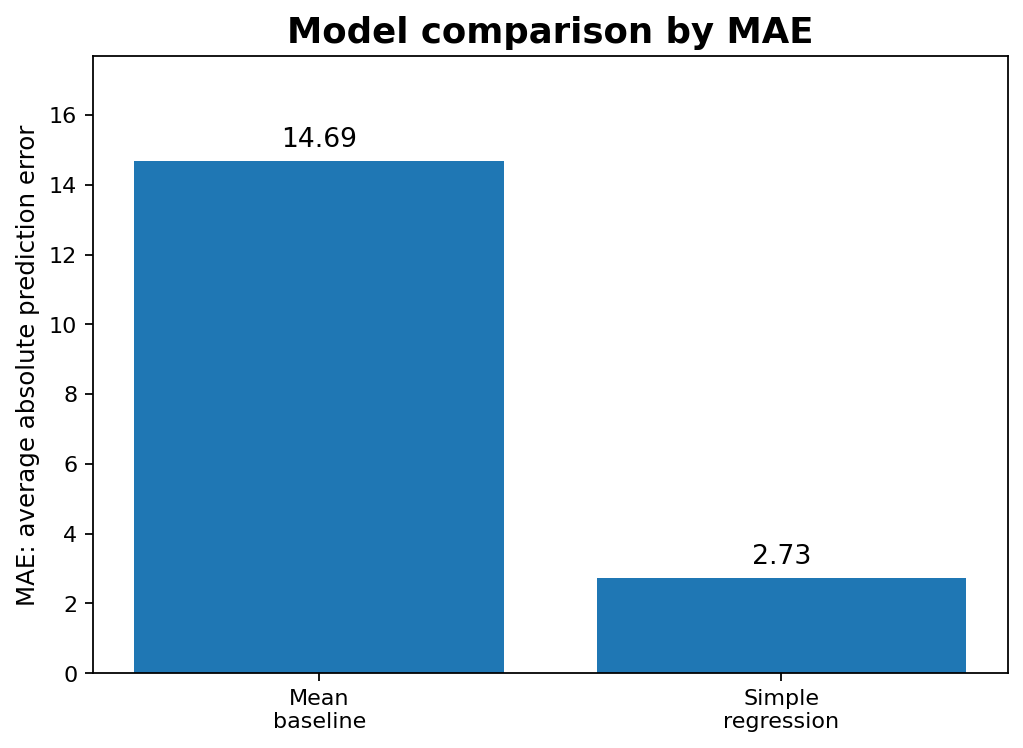

Saved figure: assets/actual_vs_predicted_test.png


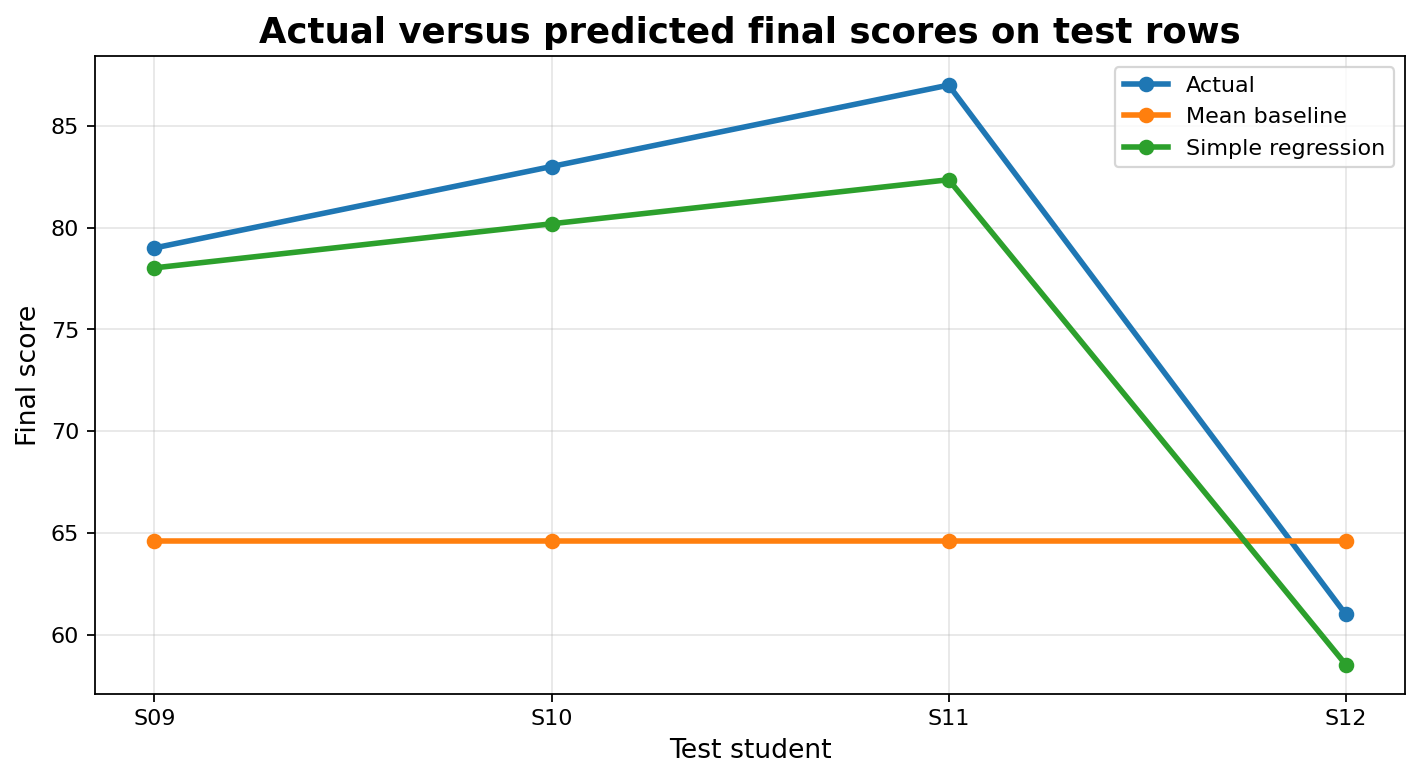

In [10]:
baseline_mae = mae(y_test, baseline_pred)
regression_mae = mae(y_test, regression_pred)

# Plot 3: model comparison by MAE
fig, ax = plt.subplots(figsize=(6.5, 4.8))
model_names = ["Mean\nbaseline", "Simple\nregression"]
mae_values = [baseline_mae, regression_mae]
bars = ax.bar(model_names, mae_values)
ax.set_title("Model comparison by MAE", fontsize=16, weight="bold")
ax.set_ylabel("MAE: average absolute prediction error", fontsize=11)
ax.set_ylim(0, max(mae_values) + 3)
for bar, value in zip(bars, mae_values):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.4, f"{value:.2f}", ha="center", fontsize=12)
save_and_show_current_figure("model_comparison_mae.png")

# Plot 4: actual versus predicted values on the test rows
test_ids = [row["student_id"] for row in test_rows]
x_positions = list(range(len(test_ids)))
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_positions, y_test, marker="o", linewidth=2.5, label="Actual")
ax.plot(x_positions, baseline_pred, marker="o", linewidth=2.5, label="Mean baseline")
ax.plot(x_positions, regression_pred, marker="o", linewidth=2.5, label="Simple regression")
ax.set_xticks(x_positions)
ax.set_xticklabels(test_ids)
ax.set_title("Actual versus predicted final scores on test rows", fontsize=16, weight="bold")
ax.set_xlabel("Test student", fontsize=12)
ax.set_ylabel("Final score", fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend()
save_and_show_current_figure("actual_vs_predicted_test.png")


## 6. Prediction table

Read the table row by row. Which prediction is closer to the actual score?

In [11]:
print(f"{'ID':<5}{'Actual':>10}{'Baseline':>12}{'Regression':>14}")
for row, actual, base_p, reg_p in zip(test_rows, y_test, baseline_pred, regression_pred):
    print(f"{row['student_id']:<5}{actual:>10.1f}{base_p:>12.1f}{reg_p:>14.1f}")

ID       Actual    Baseline    Regression
S09        79.0        64.6          78.0
S10        83.0        64.6          80.2
S11        87.0        64.6          82.4
S12        61.0        64.6          58.5


## 7. Your turn

1. Change the regression feature from `hours_studied` to `quiz_average`.
2. Recompute MAE.
3. Which one-feature regression is better on the test rows?

Hint:

```python
intercept, slope = simple_regression_fit(train_rows, "quiz_average", "final_score")
quiz_pred = simple_regression_predict(intercept, slope, test_rows, "quiz_average")
print(mae(y_test, quiz_pred))
```